In [1]:
!pip install anndata==0.8.0

In [8]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [9]:
def binary_exp(ct, gdict, marker_dict,org_g_dict, gene_ord):
    heatmap = pd.DataFrame(data = np.zeros((len(ct),len(gene_ord))),index = ct, columns = gene_ord)
    for item in ct:
        if item in marker_dict:
            for g in heatmap.columns:
                org_g = org_g_dict[g]
                if org_g in marker_dict[item]:
                    heatmap.loc[item,g] +=1
                if type(org_g) == float:
                    heatmap.loc[item,g] = np.nan
        else:
            heatmap.loc[item,:] = [np.nan for i in range(len(gene_ord))]
    return(heatmap)

In [2]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad
import math
import csv

In [3]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [4]:
otohomo = pd.read_csv('OTO_star_nothreshold_missing_le2_expressionthresh_07062026.tsv', delimiter = '\t',index_col = 'MM')

In [5]:
orthogroups = pd.read_csv('Vert_emapper_allorgs_07032026.tsv', delimiter = '\t', index_col = 'Unnamed: 0')

In [6]:
with open('Important_genes/MO_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026/MO_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026.pkl', 'rb') as f:
    marker_dict_mo = pickle.load(f)
    
with open('Important_genes/CJ_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026/CJ_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026.pkl', 'rb') as f:
    marker_dict_cj = pickle.load(f)
    
with open('Important_genes/AC_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026/AC_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026.pkl', 'rb') as f:
    marker_dict_ac = pickle.load(f)
    
with open('Important_genes/XT_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026/XT_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026.pkl', 'rb') as f:
    marker_dict_xt = pickle.load(f)
    
with open('Important_genes/DR_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026/DR_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026.pkl', 'rb') as f:
    marker_dict_dr = pickle.load(f)
    
with open('Important_genes/MM_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026/MM_cleaned_sssubclass_v3_or_hypobkgd_sigupdate_07042026.pkl', 'rb') as f:
    marker_dict_mg = pickle.load(f)

In [10]:
mm_mapping_ortho = orthogroup_mapper(orthogroups,'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups,'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups,'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups,'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups,'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [11]:
neuropep = pd.read_csv('Neuropeptides_receptors_10202025.csv')

In [11]:
neuropep

,Neuropeptide names,Receptors,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Adcyap1,Adcyap1r1,Vipr1,Vipr2,NaN,NaN,NaN
1,Adm,Calcr,NaN,NaN,NaN,NaN,NaN
2,Adm2,NaN,NaN,NaN,NaN,NaN,NaN
3,Agrp,Mc3r,Mc4r,NaN,NaN,NaN,NaN
4,Agt,Agtr1a,Agtr2,Agtr1b,NaN,NaN,NaN
...,...,...,...,...,...,...,...
90,Gnas,NaN,NaN,NaN,NaN,NaN,NaN
91,Enho,Grp19,NaN,NaN,NaN,NaN,NaN
92,Cgrp,Calcr,NaN,NaN,NaN,NaN,NaN
93,Dbi,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
R_set = set(neuropep.columns) - set(['Neuropeptide names'])

In [15]:
receptors = set(np.unique([str(x).strip() for x in neuropep[R_set].values.ravel() if pd.notna(x)]))

In [16]:
receptors

{'Adcyap1r1',
 'Adipor1',
 'Adipor2',
 'Agtr1a',
 'Agtr1b',
 'Agtr2',
 'Aplnr',
 'Avp2r',
 'Avpr1a',
 'Avpr1b',
 'Bdkrb1',
 'Bdkrb2',
 'Brs3',
 'C3ar1',
 'Calcr',
 'Cckar',
 'Cckbr',
 'Crhr1',
 'Crhr2',
 'Ednra',
 'Ednrb',
 'Galr1',
 'Galr2',
 'Galr3',
 'Gcgr',
 'Ghrhr',
 'Gipr',
 'Glp1r',
 'Gnrhr',
 'Gpr68',
 'Grp19',
 'Grpr',
 'Gshr1a',
 'Hcrtr1',
 'Hcrtr2',
 'Igf1r',
 'Igf2r',
 'Insr',
 'Kiss1r',
 'Lepr',
 'Mc1r',
 'Mc3r',
 'Mc4r',
 'Mc5r',
 'Mchr1',
 'Mchr2',
 'Mlnr',
 'Nmbr',
 'Nmur1',
 'Nmur2',
 'Npbwr1',
 'Npbwr2',
 'Npffr1',
 'Npffr2',
 'Npr1',
 'Npr2',
 'Npr3',
 'Npsr1',
 'Npy1r',
 'Npy2r',
 'Npy4r',
 'Npyr',
 'Nr3c1',
 'Ntsr1',
 'Ntsr2',
 'Oprd1',
 'Oprk1',
 'Oprl1',
 'Oprm1',
 'Oxtr',
 'Prlhr',
 'Prlr',
 'Prokr1',
 'Prokr2',
 'Pth1r',
 'Qrfpr',
 'Rxfp1',
 'Rxfp2',
 'Rxfp3',
 'Sctr',
 'Sstr1',
 'Sstr2',
 'Sstr3',
 'Sstr4',
 'Sstr5',
 'Tacr1',
 'Tacr2',
 'Tacr3',
 'Trhr',
 'Uts2r',
 'Vipr1',
 'Vipr2'}

In [17]:
'Brs3' in receptors

True

In [18]:
receptors = list(receptors)
neuropeptides = list(set(neuropep['Neuropeptide names']))

In [19]:
all_np = neuropeptides + receptors

In [20]:
len(receptors)

92

In [21]:
overall_NP_set = set(otohomo.index) & set(all_np)

In [22]:
mg_exp ={i:i for i in overall_NP_set}
mo_exp = {i:otohomo.loc[i,'MO'] for i in overall_NP_set}
cj_exp = {i:otohomo.loc[i,'CJ'] for i in overall_NP_set}
ac_exp = {i:otohomo.loc[i,'AC'] for i in overall_NP_set}
xt_exp = {i:otohomo.loc[i,'XT'] for i in overall_NP_set}
dr_exp = {i:otohomo.loc[i,'DR'] for i in overall_NP_set}

In [23]:
set(mg_exp.keys()) - set(mo_exp.keys())

set()

In [24]:
hypo_names = [i for i in marker_dict_mg.keys() if parent_dict[parent_dict[i]] == 'hypo']
hypo_names.sort()

In [25]:
fixed_gene_ord = list(mg_exp.keys())
bi_mg = binary_exp(hypo_names,mg_exp,marker_dict_mg,mg_exp,fixed_gene_ord)
bi_mo = binary_exp(hypo_names,mg_exp,marker_dict_mo,mo_exp,fixed_gene_ord)
bi_cj = binary_exp(hypo_names,mg_exp,marker_dict_cj,cj_exp,fixed_gene_ord)
bi_ac = binary_exp(hypo_names,mg_exp,marker_dict_ac,ac_exp,fixed_gene_ord)
bi_xt = binary_exp(hypo_names,mg_exp,marker_dict_xt,xt_exp,fixed_gene_ord)
bi_dr = binary_exp(hypo_names,mg_exp,marker_dict_dr,dr_exp,fixed_gene_ord)

In [26]:
bi_cj.shape

(73, 145)

In [27]:
bi_mo

,Uts2b,Brs3,Npffr2,Pmch,Tac1,Gal,Npy4r,Igf1,Pdyn,Mc4r,...,Ednrb,Nts,Npw,Npvf,C3ar1,Crh,Tacr1,Ucn,Sstr1,Mc5r
066 NDB-SI-ant Prdm12 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
073 MEA-BST Sox6 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
074 MEA-BST Lhx6 Sp9 Gaba,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
075 MEA-BST Lhx6 Nr2e1 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
076 MEA-BST Lhx6 Nfib Gaba,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140 PMd-LHA Foxb1 Glut,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
141 PH-SUM Foxa1 Glut,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
142 HY Gnrh1 Glut,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
143 MM-ant Foxb1 Glut,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [28]:
cmap = plt.cm.Blues.copy()
cmap.set_bad(color="lightgray")  # color for NaNs

<AxesSubplot:>

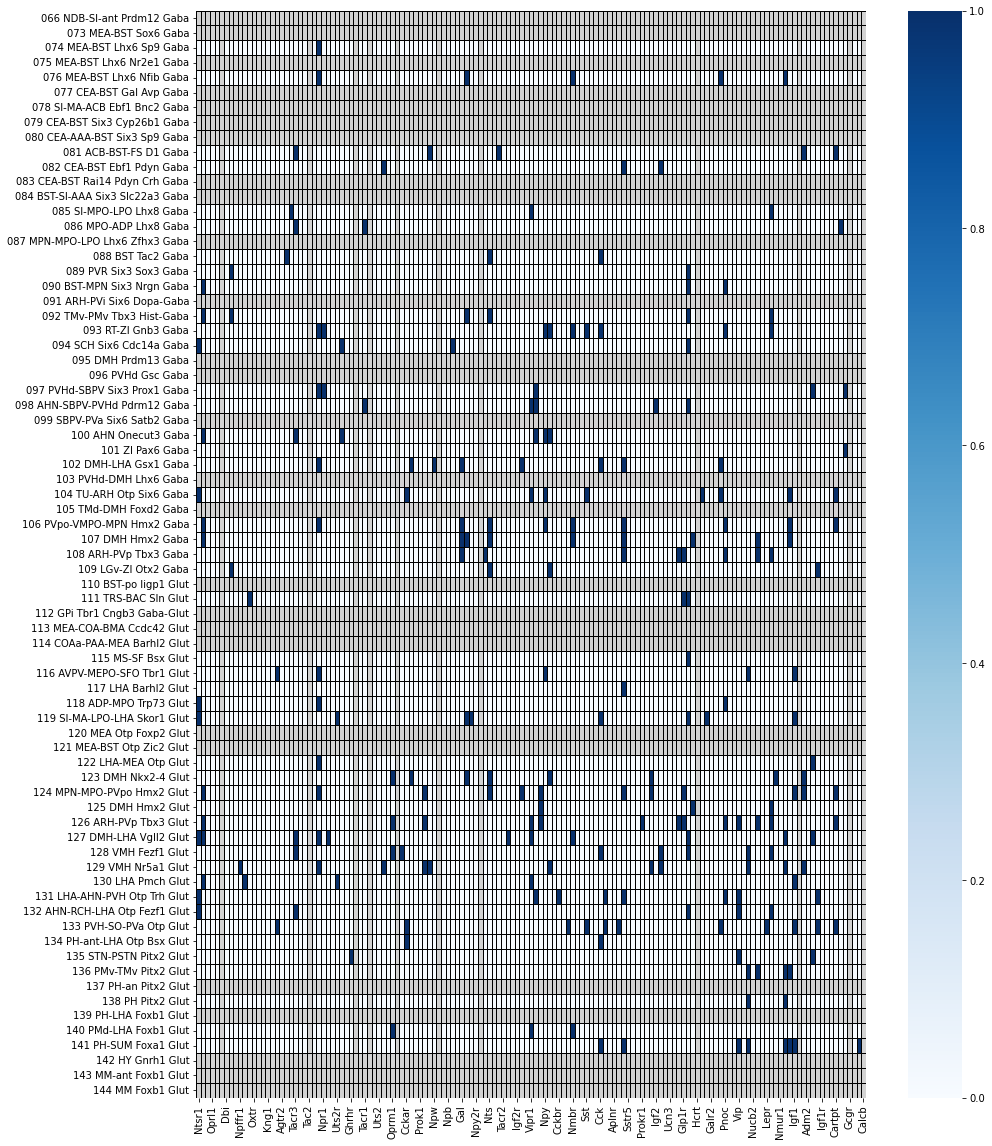

In [97]:
plt.figure(figsize=(15,20))
sns.heatmap(bi_cj, cmap = cmap,  linewidth=0.5, linecolor='black',)

In [29]:
fbi_mg = bi_mg.fillna(0)
fbi_mo = bi_mo.fillna(0)
fbi_cj = bi_cj.fillna(0)
fbi_ac = bi_ac.fillna(0)
fbi_xt = bi_xt.fillna(0)
fbi_dr = bi_dr.fillna(0)

In [30]:
fbi_all = fbi_mg + fbi_mo + fbi_cj + fbi_ac + fbi_xt + fbi_dr

In [31]:
'Crh' in fbi_all.columns

True

In [32]:
fbi_all

,Uts2b,Brs3,Npffr2,Pmch,Tac1,Gal,Npy4r,Igf1,Pdyn,Mc4r,...,Ednrb,Nts,Npw,Npvf,C3ar1,Crh,Tacr1,Ucn,Sstr1,Mc5r
066 NDB-SI-ant Prdm12 Gaba,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
073 MEA-BST Sox6 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
074 MEA-BST Lhx6 Sp9 Gaba,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
075 MEA-BST Lhx6 Nr2e1 Gaba,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
076 MEA-BST Lhx6 Nfib Gaba,0.0,2.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140 PMd-LHA Foxb1 Glut,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
141 PH-SUM Foxa1 Glut,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
142 HY Gnrh1 Glut,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
143 MM-ant Foxb1 Glut,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
num_orgs = pd.DataFrame(data = np.zeros((len(fbi_all.index),1)),columns = ['Num orgs'], index = fbi_all.index)
for item in num_orgs.index:
    if item in marker_dict_mg.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_mo.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_cj.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_ac.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_xt.keys():
        num_orgs.loc[item,'Num orgs'] +=1
    if item in marker_dict_dr.keys():
        num_orgs.loc[item,'Num orgs'] +=1

In [34]:
cts = num_orgs[num_orgs['Num orgs'] >= 4].index

In [35]:
np.sum(fbi_all, axis = 0)

Uts2b      0.0
Brs3      20.0
Npffr2    24.0
Pmch      12.0
Tac1      42.0
          ... 
Crh       22.0
Tacr1     34.0
Ucn        2.0
Sstr1     10.0
Mc5r      13.0
Length: 145, dtype: float64

In [36]:
fbi_all = fbi_all.loc[cts,:]

In [37]:
fbi_all

,Uts2b,Brs3,Npffr2,Pmch,Tac1,Gal,Npy4r,Igf1,Pdyn,Mc4r,...,Ednrb,Nts,Npw,Npvf,C3ar1,Crh,Tacr1,Ucn,Sstr1,Mc5r
073 MEA-BST Sox6 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
074 MEA-BST Lhx6 Sp9 Gaba,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
076 MEA-BST Lhx6 Nfib Gaba,0.0,2.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0
079 CEA-BST Six3 Cyp26b1 Gaba,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0
082 CEA-BST Ebf1 Pdyn Gaba,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
085 SI-MPO-LPO Lhx8 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0
086 MPO-ADP Lhx8 Gaba,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
088 BST Tac2 Gaba,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,3.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0
089 PVR Six3 Sox3 Gaba,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
090 BST-MPN Six3 Nrgn Gaba,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
total_index = fbi_all.columns[(fbi_all >= 4).any(axis=0)]

In [39]:
len(total_index)

22

In [40]:
total_index

Index(['Pmch', 'Gal', 'Igf1', 'Pdyn', 'Galr1', 'Pnoc', 'Pomc', 'Oprk1', 'Trh',
       'Sst', 'Grp', 'Avp', 'Qrfp', 'Oxt', 'Adcyap1', 'Agtr1a', 'Hcrt', 'Npy',
       'Agrp', 'Nts', 'Npvf', 'Crh'],
      dtype='object')

In [41]:
column_map = pd.DataFrame(index = fbi_all.columns, columns = ['npcolor'])
for item in fbi_all.columns:
    if item in neuropeptides:
        column_map.loc[item,'npcolor'] = 'Purple'
    else:
        column_map.loc[item,'npcolor'] = 'Green'

In [42]:
fbi_all.shape

(46, 145)

In [44]:
mg_np = []
mo_np = []
cj_np = []
ac_np= []
xt_np = []
dr_np = []
for item in fbi_all.columns:
    mg_np.append(mg_exp[item])
    mo_np.append(mo_exp[item])
    cj_np.append(cj_exp[item])
    ac_np.append(ac_exp[item])
    xt_np.append(xt_exp[item])
    dr_np.append(dr_exp[item])

In [45]:
with open("mg_np_all_07082026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(mg_np)  
    
with open("mo_np_all_07082026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(mo_np)  
    
with open("cj_np_all_07082026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(cj_np)  
    
with open("ac_np_all_07082026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(ac_np)  
    
with open("xt_np_all_07082026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(xt_np)  
    
with open("dr_np_all_07082026.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(dr_np)  

In [115]:
fbi_all.columns

Index(['Ntsr1', 'Vipr2', 'Mc1r', 'Oprl1', 'Nppc', 'Vgf', 'Dbi', 'Gnrh1',
       'Apln', 'Npffr1',
       ...
       'Igf1r', 'Ins2', 'Gcg', 'Cartpt', 'Hcrtr2', 'Brs3', 'Gcgr', 'Avpr1b',
       'Npffr2', 'Calcb'],
      dtype='object', length=145)

In [41]:
np_mapping = pd.DataFrame(data = [list(fbi_all.columns),
                     [mo_exp[i] for i in list(fbi_all.columns)],
                     [cj_exp[i]for i in list(fbi_all.columns)],
                     [ac_exp[i] for i in list(fbi_all.columns)],
                     [xt_exp[i] for i in list(fbi_all.columns)],
                     [dr_exp[i] for i in list(fbi_all.columns)]],
             index = ['Mouse gene name','Vole gene name','Quail gene name','Anole gene name','Xenopus gene name','Zebrafish gene name']).T

In [42]:
np_mapping.to_csv('NP_mapping_allorgs_Fig2_07072026.csv')

In [12]:
old_set = ['Pomc','Hcrt','Npvf','Qrfp','Adcyap1','Pdyn','Oprk1','Igf1','Pmch','Trh','Agtr1a','Oxt','Avp','Crh']

In [13]:
old_set.reverse()

In [14]:
old_set

['Crh',
 'Avp',
 'Oxt',
 'Agtr1a',
 'Trh',
 'Pmch',
 'Igf1',
 'Oprk1',
 'Pdyn',
 'Adcyap1',
 'Qrfp',
 'Npvf',
 'Hcrt',
 'Pomc']

In [15]:
reindex = ['Grp','Nts','Pnoc','Gal','Galr1','Agrp','Npy','Sst'] + old_set

In [16]:
otohomo.loc[reindex,:]

,MO,CJ,AC,XT,DR,n_species
MM,,,,,,
Grp,Grp,GRP,grp,grp,NaN,5
Nts,Nts,NTS,nts,nts,nts,6
Pnoc,Pnoc,ENSCJPG00005013002,pnoc,pnoc,pnocb,6
Gal,Gal,GAL,gal,ENSXETG00000044443,gal,6
Galr1,Galr1,GALR1,galr1,galr1,galr1a,6
Agrp,Agrp,Agrp,agrp,agrp,agrp,6
Npy,Npy,NPY,npy,npy,npy,6
Sst,Sst,SST,sst,sst.1,sst1.1,6
Crh,Crh,CRH,crh,ENSXETG00000035344,crhb,6


In [52]:
reindex

['Grp',
 'Nts',
 'Pnoc',
 'Gal',
 'Galr1',
 'Agrp',
 'Npy',
 'Sst',
 'Crh',
 'Avp',
 'Oxt',
 'Agtr1a',
 'Trh',
 'Pmch',
 'Igf1',
 'Oprk1',
 'Pdyn',
 'Adcyap1',
 'Qrfp',
 'Npvf',
 'Hcrt',
 'Pomc']

In [204]:
set(reindex) - set(fbi_all.columns)

set()

In [205]:
set(total_index) - set(reindex)

set()

In [206]:
set(reindex) - set(total_index)

set()

In [207]:
fbi_all = fbi_all.loc[:,reindex]

<AxesSubplot:>

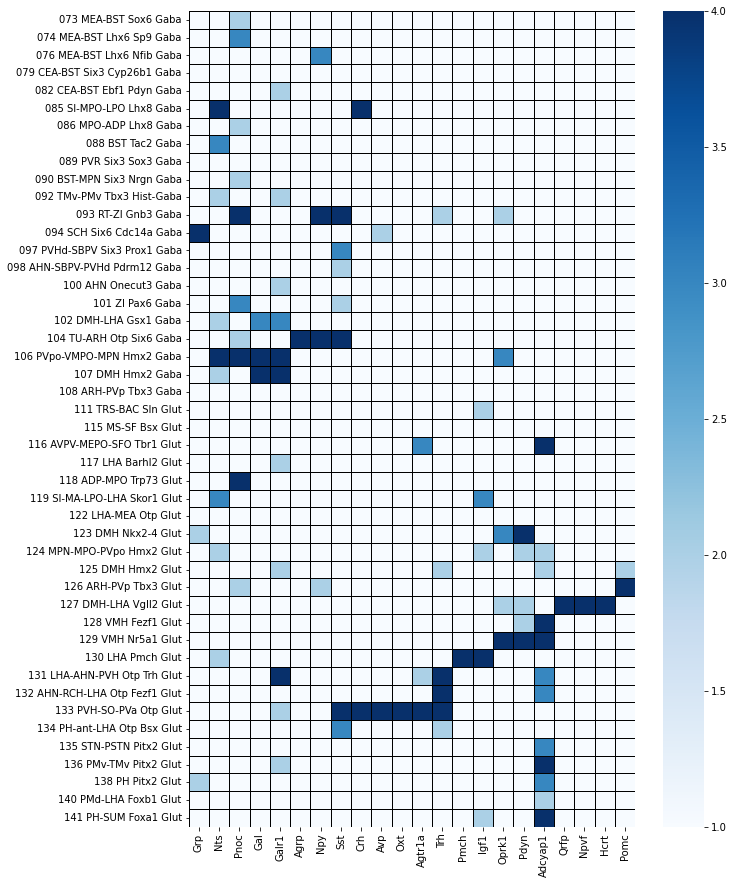

In [208]:
plt.figure(figsize=(10,15))
sns.heatmap(fbi_all, cmap = cmap,  linewidth=0.5, linecolor='black',vmax = 4, vmin = 1)

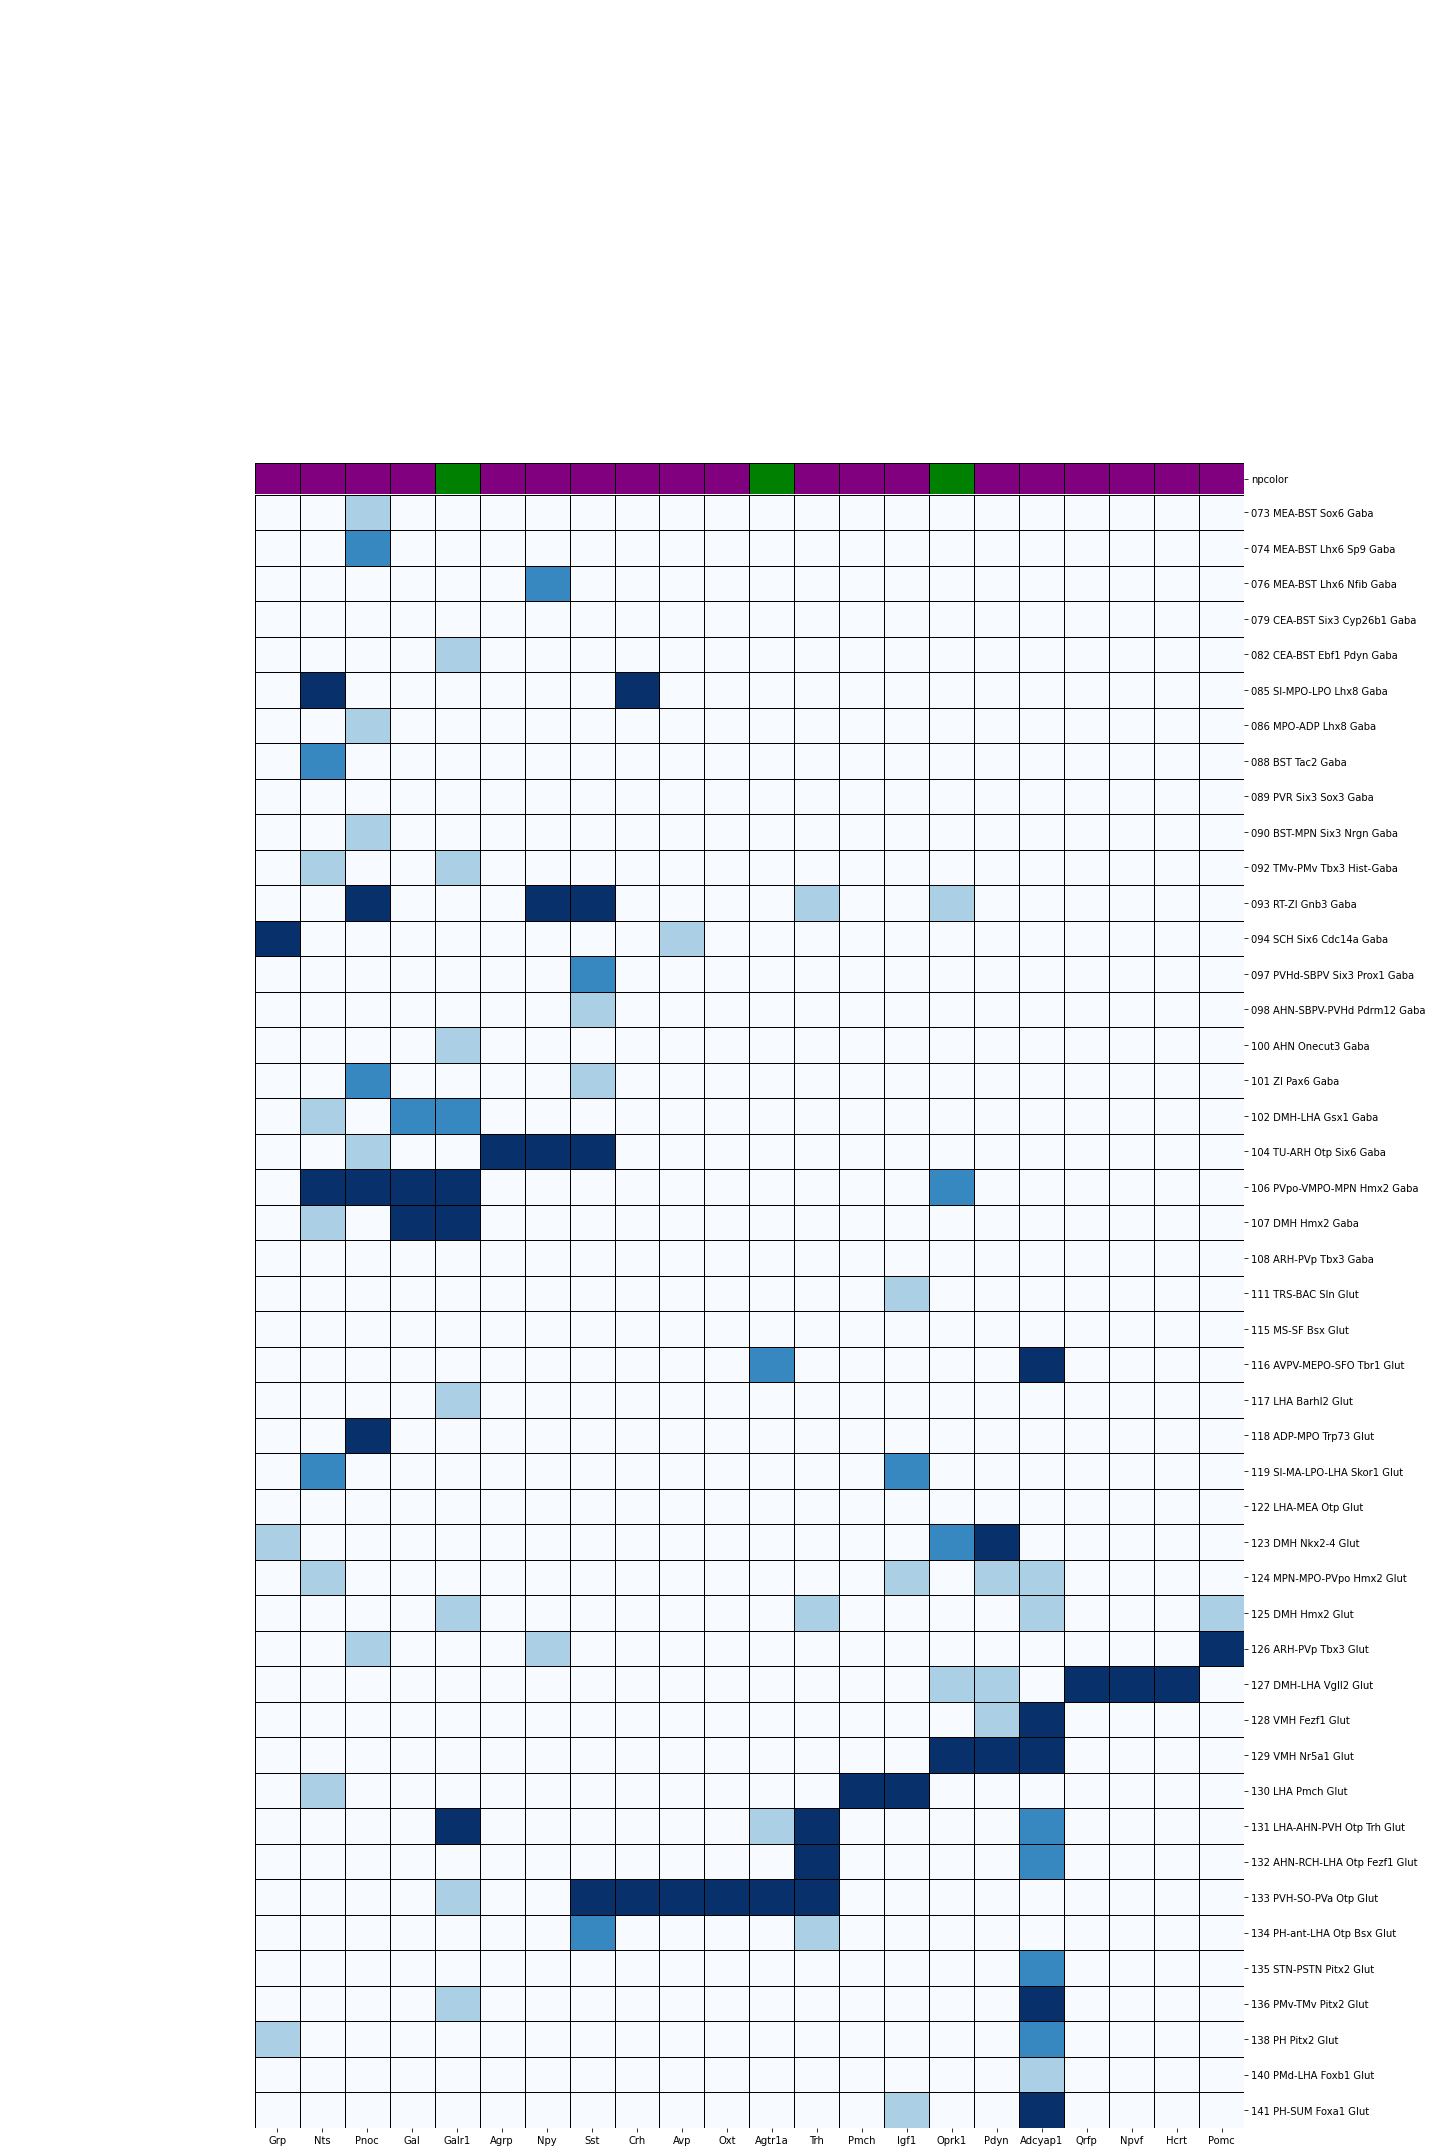

In [209]:
g = sns.clustermap(fbi_all, cmap = cmap,  linewidth=1, linecolor='black',vmax = 4, vmin = 1,col_colors = column_map, row_cluster = False, col_cluster = False, figsize = (20,30), cbar_pos = None)
#g.ax_heatmap.set_xticks([])
#g.ax_heatmap.set_yticks([])
colc_ax = g.ax_col_colors
box = colc_ax.get_position()
colc_ax.set_position([
    box.x0,              # left
    box.y0,       # bottom (shift it up a bit)
    box.width,           # keep width
    box.height * .5    # reduce height (30% of original)
])

plt.savefig('Figures/Figures_07072026/Neuropeptide_marker_conservation_missingtwo_07072026.png', dpi = 300,bbox_inches = 'tight')
plt.savefig('Figures/Figures_07072026/Neuropeptide_marker_conservation_missingtwo_07072026.svg')
plt.savefig('Figures/Figures_07072026/Neuropeptide_marker_conservation_missingtwo_07072026.pdf')